# Clasificacion con Redes Neuronales (Tabular)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/unidad_2/03_unidad/03_01_clasificacion_redes_neuronales.ipynb)

Notebook explicativo para clase: baseline clasico, red neuronal, y optimizacion bayesiana de hiperparametros.

## 1) Objetivos de aprendizaje

- Construir un pipeline completo de clasificacion binaria con PyTorch.
- Comprender y ajustar hiperparametros de entrenamiento.
- Usar optimizacion bayesiana (Optuna) para encontrar mejores configuraciones.

In [25]:
# Bootstrap de compatibilidad de entorno (NumPy 2 -> NumPy <2)
# Ejecuta esta celda una sola vez si aparece error de modulos compilados.
import sys
import subprocess

# Si quieres forzar la reparacion del entorno, cambia a True.
REPAIR_NUMPY_ENV = False

if REPAIR_NUMPY_ENV:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--user', '--upgrade', '--force-reinstall',
        'numpy<2', 'scipy', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'optuna'
    ])
    raise SystemExit('Entorno actualizado. Reinicia el kernel y vuelve a ejecutar desde el inicio.')

print('Celda de compatibilidad lista. Si hay error de NumPy 2, activa REPAIR_NUMPY_ENV=True y ejecuta.')

Celda de compatibilidad lista. Si hay error de NumPy 2, activa REPAIR_NUMPY_ENV=True y ejecuta.


Esta celda de compatibilidad evita errores de entorno (especialmente con NumPy 2 y módulos compilados). Si aparece conflicto de versiones, se corrige primero el entorno y luego se continúa con el laboratorio.

In [26]:
import random
import time
import copy
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


La detección de dispositivo confirma dónde entrenaremos el modelo. Si aparece CPU, el entrenamiento será más lento; si aparece CUDA, podremos iterar más rápido y experimentar con más configuraciones.

## Contexto del dataset

En este laboratorio usamos el dataset **Breast Cancer Wisconsin** (scikit-learn), un conjunto tabular para clasificacion binaria.

- **Objetivo**: predecir si un tumor es benigno o maligno.
- **Tipo de problema**: clasificacion supervisada binaria.
- **Unidad de analisis**: una muestra por paciente/biopsia.
- **Variable objetivo (`target`)**:
  - `0` = benigno
  - `1` = maligno

Este dataset es muy util para docencia porque combina:
- variables numericas continuas,
- tamano manejable para experimentar rapido,
- y un contexto aplicado en salud.

## Diccionario de datos (resumen)

Las 30 variables de entrada son mediciones calculadas sobre imagenes de nucleos celulares. Se agrupan en tres familias:

- **Medidas base**: `mean radius`, `mean texture`, `mean perimeter`, `mean area`, `mean smoothness`, `mean compactness`, `mean concavity`, `mean concave points`, `mean symmetry`, `mean fractal dimension`.
- **Error estandar**: mismas medidas con sufijo `error` (variabilidad de cada medicion).
- **Peor caso** (`worst`): valor mas alto/critico observado para cada medida (`worst radius`, `worst texture`, etc.).

Interpretacion general:
- Variables de **tamano**: `radius`, `perimeter`, `area`.
- Variables de **forma/borde**: `compactness`, `concavity`, `concave points`, `symmetry`, `fractal dimension`.
- Variable objetivo: `target` (`0` benigno, `1` maligno).

En clase, lo importante no es memorizar cada campo, sino entender que el modelo aprende patrones numericos asociados al diagnostico.

## 2) Cargar dataset (fuente externa a Kaggle: scikit-learn / Wisconsin)

Este dataset clasifica tumores en benigno (0) y maligno (1).

In [27]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target'] = data.target

print('Shape:', df.shape)
display(df.head())
display(df['target'].value_counts().rename('count'))

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


target
1    357
0    212
Name: count, dtype: int64

Aquí validamos tamaño del dataset y distribución de la variable objetivo. Esta lectura inicial orienta todo el modelado: balance de clases, dificultad esperada y criterios de evaluación apropiados.

In [38]:
X = df.drop(columns=['target']).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (364, 30) Val: (91, 30) Test: (114, 30)


La partición train/val/test y el escalado son pasos críticos para evitar fuga de información y asegurar evaluación honesta. Fíjense que el `StandardScaler` se ajusta solo en train y luego se aplica a val/test.

## 3) Baseline clasico (Logistic Regression)

In [29]:
baseline = LogisticRegression(max_iter=2000)
baseline.fit(X_train, y_train)

val_pred_base = baseline.predict(X_val)
val_prob_base = baseline.predict_proba(X_val)[:, 1]

print('Baseline VAL Accuracy:', accuracy_score(y_val, val_pred_base))
print('Baseline VAL F1:', f1_score(y_val, val_pred_base))
print('Baseline VAL AUC:', roc_auc_score(y_val, val_prob_base))

Baseline VAL Accuracy: 0.978021978021978
Baseline VAL F1: 0.9824561403508771
Baseline VAL AUC: 0.9979360165118679


El baseline clásico nos da una referencia objetiva. No entrenamos una red neuronal "a ciegas": primero medimos una línea base y luego verificamos si la red realmente agrega valor en métricas de validación.

## 4) Configuracion de hiperparametros (NN)

Hiperparametros cubiertos en este notebook: arquitectura, regularizacion, optimizador, scheduler, early stopping y batch size.

En esta configuracion inicial, cada hiperparametro cumple un rol especifico:

- `input_dim`: numero de variables de entrada del dataset.
- `h1`, `h2`: neuronas en la primera y segunda capa oculta (capacidad del modelo).
- `dropout`: fraccion de neuronas apagadas durante entrenamiento para reducir sobreajuste.
- `use_batchnorm`: activa normalizacion por batch para estabilizar entrenamiento.
- `activation`: funcion no lineal (por ejemplo `relu` o `gelu`).
- `batch_size`: numero de muestras por iteracion de gradiente.
- `epochs`: numero maximo de pasadas completas sobre train.
- `learning_rate`: tamano del paso de actualizacion de pesos.
- `optimizer_name`: algoritmo de optimizacion (`adam`, `adamw`, `sgd`, `rmsprop`).
- `weight_decay`: regularizacion L2 para controlar complejidad.
- `momentum`: inercia del gradiente (principalmente en SGD/RMSprop).
- `scheduler_name`: estrategia para ajustar learning rate en el tiempo.
- `scheduler_factor`: cuanto se reduce el learning rate al activar scheduler.
- `scheduler_patience`: epocas de espera antes de reducir learning rate.
- `grad_clip`: limite maximo de gradiente para evitar explosiones.
- `early_stopping_patience`: epocas sin mejora permitidas antes de detener entrenamiento.

In [30]:
@dataclass
class CFG:
    input_dim: int = X_train.shape[1]
    h1: int = 128
    h2: int = 64
    dropout: float = 0.25
    use_batchnorm: bool = True
    activation: str = 'relu'
    batch_size: int = 32
    epochs: int = 80
    learning_rate: float = 1e-3
    optimizer_name: str = 'adamw'
    weight_decay: float = 1e-4
    momentum: float = 0.9
    scheduler_name: str = 'plateau'
    scheduler_factor: float = 0.5
    scheduler_patience: int = 4
    grad_clip: float = 1.0
    early_stopping_patience: int = 12

cfg = CFG()
cfg

CFG(input_dim=30, h1=128, h2=64, dropout=0.25, use_batchnorm=True, activation='relu', batch_size=32, epochs=80, learning_rate=0.001, optimizer_name='adamw', weight_decay=0.0001, momentum=0.9, scheduler_name='plateau', scheduler_factor=0.5, scheduler_patience=4, grad_clip=1.0, early_stopping_patience=12)

Este bloque muestra los hiperparámetros iniciales con los que partimos. Trátenlos como hipótesis de trabajo: no son "los mejores" por definición, sino un punto de partida que luego validamos y mejoramos con evidencia.

In [31]:
def make_loaders(cfg):
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
    Xte = torch.tensor(X_test, dtype=torch.float32)
    yte = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xv, yv), batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=cfg.batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


class MLPClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act = nn.ReLU() if cfg.activation == 'relu' else nn.GELU()
        layers = [nn.Linear(cfg.input_dim, cfg.h1)]
        if cfg.use_batchnorm:
            layers.append(nn.BatchNorm1d(cfg.h1))
        layers += [act, nn.Dropout(cfg.dropout), nn.Linear(cfg.h1, cfg.h2)]
        if cfg.use_batchnorm:
            layers.append(nn.BatchNorm1d(cfg.h2))
        layers += [act, nn.Dropout(cfg.dropout), nn.Linear(cfg.h2, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_optimizer(model, cfg):
    name = cfg.optimizer_name.lower()
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=cfg.learning_rate, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    return torch.optim.RMSprop(model.parameters(), lr=cfg.learning_rate, momentum=cfg.momentum, weight_decay=cfg.weight_decay)


def make_scheduler(optimizer, cfg):
    if cfg.scheduler_name == 'plateau':
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
    if cfg.scheduler_name == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    return None

Antes de entrenar, revisamos la arquitectura de la red para que quede claro qué se está modelando:
- cantidad de capas ocultas,
- neuronas por capa,
- activaciones,
- dropout,
- total de parámetros entrenables.

Esta lectura ayuda a relacionar diseño de red con capacidad de aprendizaje y riesgo de sobreajuste.

In [32]:
# Resumen didactico de la arquitectura antes de entrenar
train_loader, val_loader, test_loader = make_loaders(cfg)
model_preview = MLPClassifier(cfg).to(device)

# Tomamos un batch para ver shapes reales del pipeline
xb_preview, yb_preview = next(iter(train_loader))
xb_preview = xb_preview.to(device)
with torch.no_grad():
    logits_preview = model_preview(xb_preview)

print('=== RESUMEN DE ARQUITECTURA ===')
print(f'Input dim: {cfg.input_dim}')
print(f'Capas ocultas: 2')
print(f'Neuronas capa oculta 1 (h1): {cfg.h1}')
print(f'Neuronas capa oculta 2 (h2): {cfg.h2}')
print(f'Activacion: {cfg.activation.upper()}')
print(f'BatchNorm: {cfg.use_batchnorm}')
print(f'Dropout: {cfg.dropout}')
print(f'Salida: 1 logit (clasificacion binaria)')

trainable_params = sum(p.numel() for p in model_preview.parameters() if p.requires_grad)
print(f'Parametros entrenables: {trainable_params:,}')

print('\n=== SHAPES DEL FLUJO ===')
print('X batch:', tuple(xb_preview.shape))
print('y batch:', tuple(yb_preview.shape))
print('logits batch:', tuple(logits_preview.shape))
print('Interpretacion: por cada muestra se produce 1 logit, luego se aplica sigmoide para probabilidad.')

=== RESUMEN DE ARQUITECTURA ===
Input dim: 30
Capas ocultas: 2
Neuronas capa oculta 1 (h1): 128
Neuronas capa oculta 2 (h2): 64
Activacion: RELU
BatchNorm: True
Dropout: 0.25
Salida: 1 logit (clasificacion binaria)
Parametros entrenables: 12,673

=== SHAPES DEL FLUJO ===
X batch: (32, 30)
y batch: (32, 1)
logits batch: (32, 1)
Interpretacion: por cada muestra se produce 1 logit, luego se aplica sigmoide para probabilidad.


Este resumen de arquitectura es clave para justificar decisiones de diseño. Observen cómo cada muestra produce un único logit para clasificación binaria y cómo el número de parámetros cambia la capacidad del modelo y el riesgo de sobreajuste.

## 5) Entrenamiento de la red neuronal

In [33]:
def eval_binary(model, loader):
    model.eval()
    ys, ps, logits_all = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            prob = torch.sigmoid(logits)
            ys.append(yb.numpy())
            ps.append(prob.cpu().numpy())
            logits_all.append(logits.cpu().numpy())
    y_true = np.vstack(ys).ravel()
    y_prob = np.vstack(ps).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'acc': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob)
    }


def train_model(cfg):
    train_loader, val_loader, test_loader = make_loaders(cfg)
    model = MLPClassifier(cfg).to(device)
    optimizer = make_optimizer(model, cfg)
    scheduler = make_scheduler(optimizer, cfg)
    criterion = nn.BCEWithLogitsLoss()

    history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}
    best_state = None
    best_val_f1 = -1
    patience_count = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            losses.append(loss.item())

        val_metrics = eval_binary(model, val_loader)
        tr_loss = float(np.mean(losses))
        history['train_loss'].append(tr_loss)
        history['val_acc'].append(val_metrics['acc'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        if scheduler is not None:
            if cfg.scheduler_name == 'plateau':
                scheduler.step(val_metrics['f1'])
            else:
                scheduler.step()

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_f1={val_metrics['f1']:.4f} | val_auc={val_metrics['auc']:.4f}")

        if patience_count >= cfg.early_stopping_patience:
            print(f"Early stopping en epoca {epoch}")
            break

    model.load_state_dict(best_state)
    val_metrics = eval_binary(model, val_loader)
    test_metrics = eval_binary(model, test_loader)
    return model, history, val_metrics, test_metrics


model, history, val_metrics, test_metrics = train_model(cfg)
print('VAL:', val_metrics)
print('TEST:', test_metrics)

Epoch 001 | train_loss=0.4653 | val_f1=0.9655 | val_auc=0.9928
Epoch 010 | train_loss=0.1050 | val_f1=0.9913 | val_auc=0.9979
Early stopping en epoca 15
VAL: {'acc': 0.989010989010989, 'precision': 0.9827586206896551, 'recall': 1.0, 'f1': 0.991304347826087, 'auc': 0.9969040247678018}
TEST: {'acc': 0.9649122807017544, 'precision': 0.9722222222222222, 'recall': 0.9722222222222222, 'f1': 0.9722222222222222, 'auc': 0.9930555555555556}


En el log por época, prioricen interpretar tendencia más que una sola cifra: buscamos estabilidad en validación (`val_f1`, `val_auc`) y no solo mejora en entrenamiento. Si hay brecha creciente entre train y val, estamos memorizando más de lo deseado.

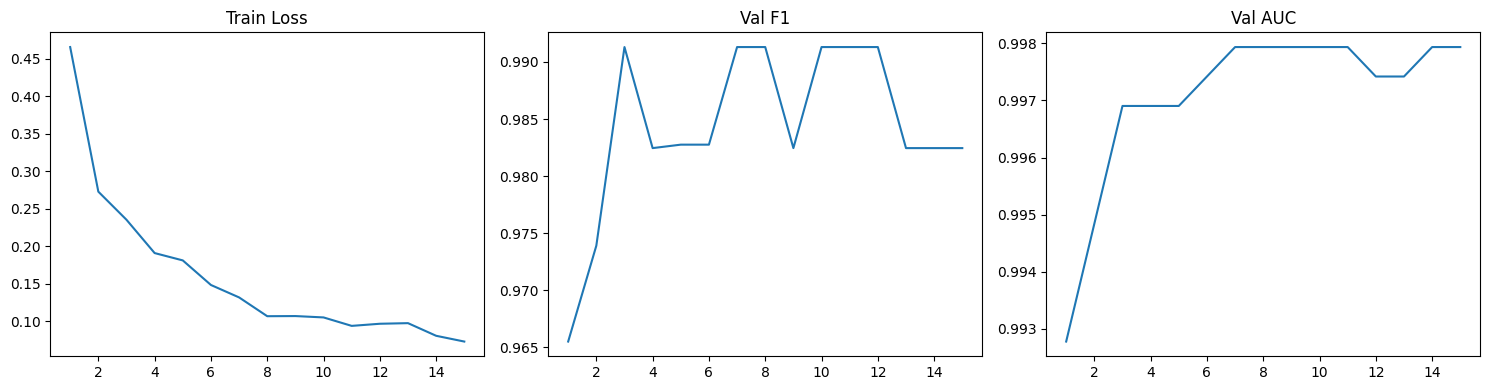

In [34]:
epochs_axis = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_axis, history['train_loss'])
axes[0].set_title('Train Loss')
axes[1].plot(epochs_axis, history['val_f1'])
axes[1].set_title('Val F1')
axes[2].plot(epochs_axis, history['val_auc'])
axes[2].set_title('Val AUC')
plt.tight_layout()
plt.show()

Las curvas de entrenamiento deben leerse en conjunto: `train_loss`, `val_f1` y `val_auc`. Si `train_loss` baja pero `val_f1` deja de mejorar, hay indicio de sobreajuste. Ese contraste es el que justifica usar early stopping y regularización.

## 6) Optimizacion bayesiana de hiperparametros (Optuna)

Buscamos mejorar F1 de validacion con TPE (modelo secuencial bayesiano).

En la optimizacion bayesiana vamos a maximizar `val_f1` y Optuna propondrá combinaciones de hiperparametros en cada trial.

Hiperparametros que se optimizan en este notebook:
- Arquitectura: `h1`, `h2`, `dropout`, `use_batchnorm`, `activation`
- Entrenamiento: `batch_size`, `learning_rate`, `grad_clip`
- Optimizador: `optimizer_name`, `momentum`, `weight_decay`
- Scheduler: `scheduler_name`, `scheduler_factor`, `scheduler_patience`

La idea es reemplazar prueba/error manual por una busqueda guiada por resultados previos.

In [35]:
# Resumen previo de la optimizacion bayesiana
search_space_resume = {
    'h1': '[32, 256] paso 32',
    'h2': '[16, 128] paso 16',
    'dropout': '[0.0, 0.5]',
    'use_batchnorm': '{True, False}',
    'activation': "{'relu', 'gelu'}",
    'batch_size': '{16, 32, 64}',
    'learning_rate': '[1e-4, 5e-2] log',
    'optimizer_name': "{'adam', 'adamw', 'sgd', 'rmsprop'}",
    'weight_decay': '[1e-7, 1e-2] log',
    'momentum': '[0.7, 0.99]',
    'scheduler_name': "{'plateau', 'cosine', 'none'}",
    'scheduler_factor': '[0.2, 0.8]',
    'scheduler_patience': '[2, 6]',
    'grad_clip': '[0.5, 5.0]'
}

print('Objetivo de Optuna: maximizar VAL F1')
print('Trials configurados: 20')
print('\nEspacio de busqueda:')
for k, v in search_space_resume.items():
    print(f'- {k}: {v}')

Objetivo de Optuna: maximizar VAL F1
Trials configurados: 20

Espacio de busqueda:
- h1: [32, 256] paso 32
- h2: [16, 128] paso 16
- dropout: [0.0, 0.5]
- use_batchnorm: {True, False}
- activation: {'relu', 'gelu'}
- batch_size: {16, 32, 64}
- learning_rate: [1e-4, 5e-2] log
- optimizer_name: {'adam', 'adamw', 'sgd', 'rmsprop'}
- weight_decay: [1e-7, 1e-2] log
- momentum: [0.7, 0.99]
- scheduler_name: {'plateau', 'cosine', 'none'}
- scheduler_factor: [0.2, 0.8]
- scheduler_patience: [2, 6]
- grad_clip: [0.5, 5.0]


Antes de correr la optimización, revisen este espacio de búsqueda y pregúntense si es realista para el tiempo de clase. Un buen diseño pedagógico no es buscar "todo", sino elegir rangos razonables que permitan aprender con evidencia en pocos trials.

In [36]:
def objective(trial):
    trial_cfg = CFG(
        input_dim=X_train.shape[1],
        h1=trial.suggest_int('h1', 32, 256, step=32),
        h2=trial.suggest_int('h2', 16, 128, step=16),
        dropout=trial.suggest_float('dropout', 0.0, 0.5),
        use_batchnorm=trial.suggest_categorical('use_batchnorm', [True, False]),
        activation=trial.suggest_categorical('activation', ['relu', 'gelu']),
        batch_size=trial.suggest_categorical('batch_size', [16, 32, 64]),
        epochs=45,
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 5e-2, log=True),
        optimizer_name=trial.suggest_categorical('optimizer_name', ['adam', 'adamw', 'sgd', 'rmsprop']),
        weight_decay=trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True),
        momentum=trial.suggest_float('momentum', 0.7, 0.99),
        scheduler_name=trial.suggest_categorical('scheduler_name', ['plateau', 'cosine', 'none']),
        scheduler_factor=trial.suggest_float('scheduler_factor', 0.2, 0.8),
        scheduler_patience=trial.suggest_int('scheduler_patience', 2, 6),
        grad_clip=trial.suggest_float('grad_clip', 0.5, 5.0),
        early_stopping_patience=8,
    )

    _, _, val_m, _ = train_model(trial_cfg)
    return val_m['f1']


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=False)

print('Best VAL F1:', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-04-17 01:39:25,441] A new study created in memory with name: no-name-f43ddf2a-7a69-416f-b35b-ba96004236ff


Epoch 001 | train_loss=0.7080 | val_f1=0.8000 | val_auc=0.8514


[I 2026-04-17 01:39:26,014] Trial 0 finished with value: 0.9661016949152542 and parameters: {'h1': 96, 'h2': 128, 'dropout': 0.36599697090570255, 'use_batchnorm': True, 'activation': 'relu', 'batch_size': 16, 'learning_rate': 0.00011364672700011186, 'optimizer_name': 'adam', 'weight_decay': 8.260808399079598e-07, 'momentum': 0.7882302504582659, 'scheduler_name': 'plateau', 'scheduler_factor': 0.5671117368334277, 'scheduler_patience': 2, 'grad_clip': 1.8146509184084816}. Best is trial 0 with value: 0.9661016949152542.


Epoch 010 | train_loss=0.3069 | val_f1=0.9661 | val_auc=0.9881
Early stopping en epoca 13
Epoch 001 | train_loss=0.2801 | val_f1=0.9735 | val_auc=0.9954


[I 2026-04-17 01:39:26,440] Trial 1 finished with value: 0.991304347826087 and parameters: {'h1': 96, 'h2': 64, 'dropout': 0.3925879806965068, 'use_batchnorm': False, 'activation': 'relu', 'batch_size': 16, 'learning_rate': 0.03639264345367794, 'optimizer_name': 'adam', 'weight_decay': 0.00026373339933815276, 'momentum': 0.8276442231844844, 'scheduler_name': 'cosine', 'scheduler_factor': 0.7455922412472693, 'scheduler_patience': 3, 'grad_clip': 3.481350279592919}. Best is trial 1 with value: 0.991304347826087.


...

Epoch 020 | train_loss=0.1278 | val_f1=0.9825 | val_auc=0.9969
Early stopping en epoca 22
Epoch 001 | train_loss=0.5779 | val_f1=0.9573 | val_auc=0.9850


[I 2026-04-17 01:39:37,054] Trial 18 finished with value: 0.9827586206896551 and parameters: {'h1': 128, 'h2': 112, 'dropout': 0.4412544406948945, 'use_batchnorm': False, 'activation': 'relu', 'batch_size': 32, 'learning_rate': 0.0012510007229159464, 'optimizer_name': 'adamw', 'weight_decay': 0.0016157696962081326, 'momentum': 0.7636412251556062, 'scheduler_name': 'cosine', 'scheduler_factor': 0.6905809332397573, 'scheduler_patience': 5, 'grad_clip': 3.6018964857182647}. Best is trial 1 with value: 0.991304347826087.


Epoch 010 | train_loss=0.0527 | val_f1=0.9825 | val_auc=0.9959
Early stopping en epoca 13
Epoch 001 | train_loss=0.2669 | val_f1=0.9825 | val_auc=0.9969


[I 2026-04-17 01:39:37,270] Trial 19 finished with value: 0.991304347826087 and parameters: {'h1': 224, 'h2': 80, 'dropout': 0.10903275564191148, 'use_batchnorm': True, 'activation': 'gelu', 'batch_size': 64, 'learning_rate': 0.01911419787739789, 'optimizer_name': 'adam', 'weight_decay': 0.0001023442841978488, 'momentum': 0.8290060246890077, 'scheduler_name': 'plateau', 'scheduler_factor': 0.5134119067783998, 'scheduler_patience': 3, 'grad_clip': 4.245590427346449}. Best is trial 1 with value: 0.991304347826087.


Epoch 010 | train_loss=0.0544 | val_f1=0.9735 | val_auc=0.9964
Early stopping en epoca 10
Best VAL F1: 0.991304347826087
Best params:
  h1: 96
  h2: 64
  dropout: 0.3925879806965068
  use_batchnorm: False
  activation: relu
  batch_size: 16
  learning_rate: 0.03639264345367794
  optimizer_name: adam
  weight_decay: 0.00026373339933815276
  momentum: 0.8276442231844844
  scheduler_name: cosine
  scheduler_factor: 0.7455922412472693
  scheduler_patience: 3
  grad_clip: 3.481350279592919


Este bloque de salida de Optuna les muestra cómo evoluciona la búsqueda por trials. Lo importante es notar que no prueba combinaciones al azar puro: usa resultados previos para proponer mejores candidatos y converger más rápido hacia configuraciones de alto desempeño.

In [37]:
best_cfg = CFG(
    input_dim=X_train.shape[1],
    h1=study.best_params['h1'],
    h2=study.best_params['h2'],
    dropout=study.best_params['dropout'],
    use_batchnorm=study.best_params['use_batchnorm'],
    activation=study.best_params['activation'],
    batch_size=study.best_params['batch_size'],
    epochs=80,
    learning_rate=study.best_params['learning_rate'],
    optimizer_name=study.best_params['optimizer_name'],
    weight_decay=study.best_params['weight_decay'],
    momentum=study.best_params['momentum'],
    scheduler_name=study.best_params['scheduler_name'],
    scheduler_factor=study.best_params['scheduler_factor'],
    scheduler_patience=study.best_params['scheduler_patience'],
    grad_clip=study.best_params['grad_clip'],
    early_stopping_patience=12,
)

best_model, best_history, best_val_metrics, best_test_metrics = train_model(best_cfg)

print('\n=== COMPARACION FINAL ===')
print('Baseline VAL F1:', f1_score(y_val, val_pred_base))
print('NN (manual) VAL F1:', val_metrics['f1'])
print('NN (bayes) VAL F1:', best_val_metrics['f1'])

print('\nNN (bayes) TEST metrics:')
print(best_test_metrics)

Epoch 001 | train_loss=0.4274 | val_f1=0.9735 | val_auc=0.9943
Epoch 010 | train_loss=0.1132 | val_f1=0.9825 | val_auc=0.9969
Early stopping en epoca 17

=== COMPARACION FINAL ===
Baseline VAL F1: 0.9824561403508771
NN (manual) VAL F1: 0.991304347826087
NN (bayes) VAL F1: 0.991304347826087

NN (bayes) TEST metrics:
{'acc': 0.9736842105263158, 'precision': 0.9726027397260274, 'recall': 0.9861111111111112, 'f1': 0.9793103448275862, 'auc': 0.9937169312169313}


Al comparar baseline, red neuronal manual y red optimizada por búsqueda bayesiana, fíjense en la mejora relativa y no solo en el valor absoluto. Si la ganancia es pequeña pero consistente, sigue siendo valiosa porque fue lograda con una configuración más robusta y reproducible.

## 7) Conclusiones 

- El baseline clasico establece una referencia fuerte.
- La red neuronal mejora cuando se ajustan hiperparametros de manera sistematica.
- La optimizacion bayesiana reduce prueba/error manual y encuentra buenas configuraciones mas rapido.
- En problemas tabulares, la ganancia de NN depende del preprocesamiento y la calibracion de hiperparametros.